In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Carga y validacion de datos 

In [4]:
RESULTS_FILE = "../../results.json"

with open(RESULTS_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

### Resumen general realizado por "results.json"

In [5]:
summary = data["summary"]

print("Organización:", summary["organization"])
print("Repositorios totales:", summary["total_repositories"])
print("Repositorios analizados:", summary["analyzed_repositories"])
print("Repositorios no soportados:", summary["unsupported_repositories"])
print("Repositorios fallidos:", summary["failed_repositories"])
print("Hallazgos totales:", summary["total_findings"])

Organización: expressjs
Repositorios totales: 50
Repositorios analizados: 41
Repositorios no soportados: 9
Repositorios fallidos: 0
Hallazgos totales: 307


### Tabla con los 307 hallazgos encontrados en "results.json"

In [6]:
findings = []

for repo in data["repositories"]:

    repo_name = repo["name"]

    for finding in repo.get("findings", []):

        findings.append({
            "repository": repo_name,
            "rule_id": finding.get("rule_id"),
            "severity": finding.get("severity"),
            "message": finding.get("message"),
            "file": finding.get("file"),
            "start_line": finding.get("start_line"),
            "language": finding.get("language")
        })

df_findings = pd.DataFrame(findings)

In [7]:
df_findings.head()

,repository,rule_id,severity,message,file,start_line,language
0,badgeboard,js/prototype-pollution-utility,warning,Properties are copied from [stuff](1) to [obj]...,scripts/config.js,83,JavaScript
1,badgeboard,js/unused-local-variable,note,Unused function getUserInfo.,scripts/make-db.js,62,JavaScript
2,badgeboard,js/conditional-comment,warning,Do not use conditional comments.,static/sorttable.js,19,JavaScript
3,badgeboard,js/missing-variable-declaration,warning,"Variable the is used like a local variable, bu...",static/sorttable.js,46,JavaScript
4,badgeboard,js/missing-variable-declaration,warning,Variable sortbottomrows is used like a local v...,static/sorttable.js,59,JavaScript


## Analisis de hallazgos por severidad

In [18]:
severity_counts = df_findings["severity"].value_counts()

severity_percentage = (
    df_findings["severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

severity_summary = pd.DataFrame({
    "cantidad": severity_counts,
    "porcentaje": severity_percentage
})

severity_summary

,cantidad,porcentaje
severity,,
note,152,49.51
warning,124,40.39
error,31,10.10


Este gráfico responde:
¿Qué nivel de severidad predomina en los resultados analizados?



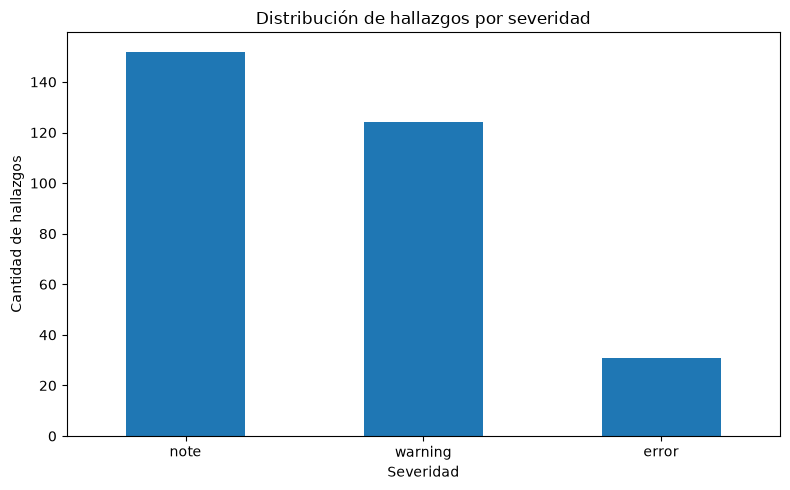

In [17]:
severity_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribución de hallazgos por severidad")
plt.xlabel("Severidad")
plt.ylabel("Cantidad de hallazgos")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Top 10 de repositorios que concentran mas hallazgos:
¿Qué repositorios concentran más hallazgos de seguridad?

In [18]:
findings_by_repo = (
    df_findings["repository"]
    .value_counts()
)

findings_by_repo.head(10)

repository
codemod             127
badgeboard           42
express              34
vhost                17
express-expose       14
body-parser          13
perf-wg              11
urlrouter             8
express-paginate      7
connect-markdown      5
Name: count, dtype: int64

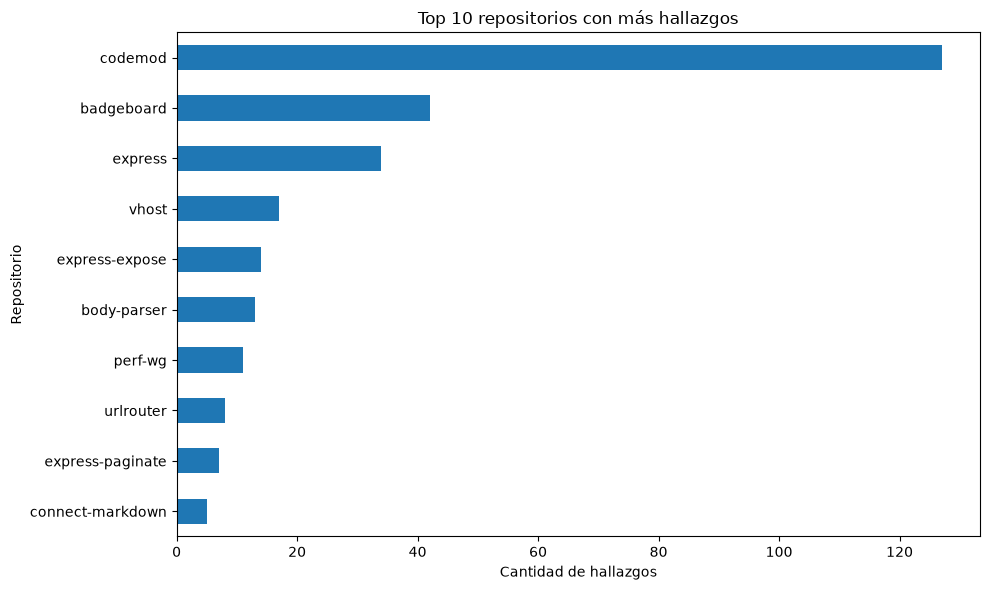

In [19]:
findings_by_repo.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 repositorios con más hallazgos")
plt.xlabel("Cantidad de hallazgos")
plt.ylabel("Repositorio")
plt.tight_layout()

plt.show()

Top 15 de los problema mas frecuentes

In [20]:
top_rules = (
    df_findings["rule_id"]
    .value_counts()
)

top_rules.head(15)

rule_id
js/unused-local-variable                  116
js/automatic-semicolon-insertion           35
js/missing-rate-limiting                   35
js/missing-variable-declaration            32
js/regex/missing-regexp-anchor             21
js/log-injection                           11
js/reflected-xss                           10
js/xss-through-exception                    4
js/clear-text-cookie                        4
js/deletion-of-non-property                 3
js/functionality-from-untrusted-domain      3
js/useless-assignment-to-local              3
js/conditional-comment                      2
js/trivial-conditional                      2
js/superfluous-trailing-arguments           2
Name: count, dtype: int64

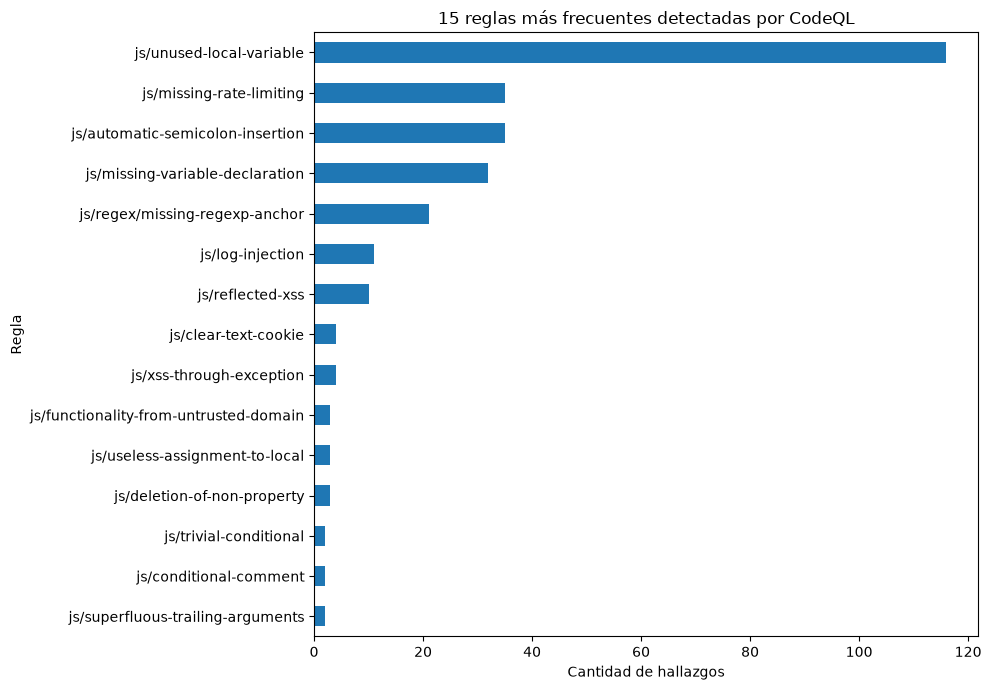

In [21]:
top_rules.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("15 reglas más frecuentes detectadas por CodeQL")
plt.xlabel("Cantidad de hallazgos")
plt.ylabel("Regla")
plt.tight_layout()

plt.show()

## La siguiente seccion busca poder separar los hallazgos de seguridad con los de calidad de calidad

Lista de todas las reglas de tipo .unique()

In [19]:
sorted(df_findings["rule_id"].unique())

['js/automatic-semicolon-insertion',
 'js/clear-text-cookie',
 'js/clear-text-logging',
 'js/conditional-comment',
 'js/cors-permissive-configuration',
 'js/deletion-of-non-property',
 'js/functionality-from-untrusted-domain',
 'js/incomplete-hostname-regexp',
 'js/incomplete-multi-character-sanitization',
 'js/incomplete-sanitization',
 'js/insufficient-password-hash',
 'js/log-injection',
 'js/missing-rate-limiting',
 'js/missing-token-validation',
 'js/missing-variable-declaration',
 'js/node/assignment-to-exports-variable',
 'js/path-injection',
 'js/prototype-polluting-assignment',
 'js/prototype-pollution-utility',
 'js/reflected-xss',
 'js/regex-injection',
 'js/regex/duplicate-in-character-class',
 'js/regex/missing-regexp-anchor',
 'js/remote-property-injection',
 'js/stack-trace-exposure',
 'js/superfluous-trailing-arguments',
 'js/trivial-conditional',
 'js/type-confusion-through-parameter-tampering',
 'js/unneeded-defensive-code',
 'js/unused-local-variable',
 'js/useless-a

Palabras clave para poder clasificar los hallazgos de seguridad

In [63]:
security_rules = [
    "js/clear-text-cookie",
    "js/clear-text-logging",
    "js/cors-permissive-configuration",
    "js/functionality-from-untrusted-domain",
    "js/incomplete-hostname-regexp",
    "js/incomplete-multi-character-sanitization",
    "js/incomplete-sanitization",
    "js/insufficient-password-hash",
    "js/log-injection",
    "js/missing-rate-limiting",
    "js/missing-token-validation",
    "js/path-injection",
    "js/prototype-polluting-assignment",
    "js/prototype-pollution-utility",
    "js/reflected-xss",
    "js/regex-injection",
    "js/remote-property-injection",
    "js/stack-trace-exposure",
    "js/type-confusion-through-parameter-tampering",
    "js/weak-cryptographic-algorithm",
    "js/xss-through-exception"
]

In [64]:
def classify_finding(rule_id):
    if rule_id in security_rules:
        return "security"
    return "code_quality"

df_findings["category"] = df_findings["rule_id"].apply(classify_finding)

In [65]:
df_findings["category"].value_counts()

category
code_quality    222
security         85
Name: count, dtype: int64

In [66]:
df_findings["category"].value_counts(
    normalize=True
).mul(100).round(2)

category
code_quality    72.31
security        27.69
Name: proportion, dtype: float64

Grafico de seguridad vs calidad

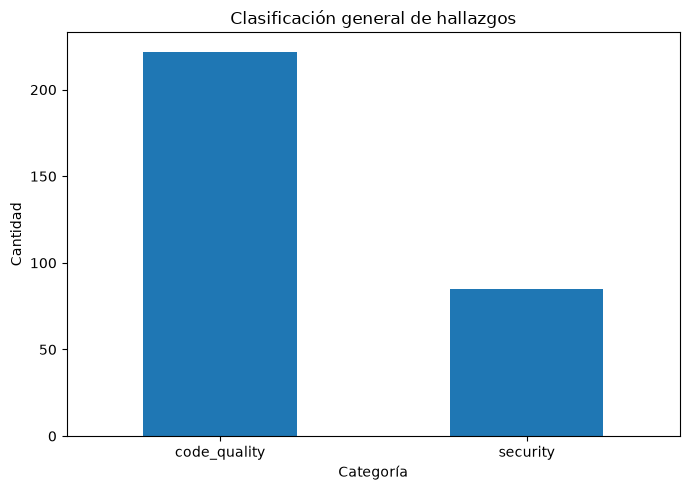

In [68]:
df_findings["category"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Clasificación general de hallazgos")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Un 72.31% corresponde a problemas directamente relacionados con la calidad o la mantenibilidad del codigo, mientras que un 27.69% estan relacionados con seguridad.

## Hallazgos de seguridad

In [69]:
df_security = df_findings[
    df_findings["category"] == "security"
].copy()

df_security.shape

(85, 8)

Tabla de los hallazgos de seguridad


In [70]:
df_security.head()

,repository,rule_id,severity,message,file,start_line,language,category
0,badgeboard,js/prototype-pollution-utility,warning,Properties are copied from [stuff](1) to [obj]...,scripts/config.js,83,JavaScript,security
42,body-parser,js/log-injection,error,Log entry depends on a [user-provided value](1).,lib/read.js,63,JavaScript,security
43,body-parser,js/log-injection,error,Log entry depends on a [user-provided value](1).,lib/read.js,193,JavaScript,security
45,body-parser,js/stack-trace-exposure,warning,This information exposed to the user depends o...,test/json.js,775,JavaScript,security
46,body-parser,js/xss-through-exception,warning,[Exception text](1) is reinterpreted as HTML w...,test/json.js,775,JavaScript,security


Analisis de las reglas de vulnerabilidad de seguridad

In [71]:
df_security["rule_id"].value_counts()

rule_id
js/missing-rate-limiting                         35
js/log-injection                                 11
js/reflected-xss                                 10
js/xss-through-exception                          4
js/clear-text-cookie                              4
js/functionality-from-untrusted-domain            3
js/path-injection                                 2
js/remote-property-injection                      2
js/type-confusion-through-parameter-tampering     2
js/prototype-pollution-utility                    1
js/stack-trace-exposure                           1
js/cors-permissive-configuration                  1
js/clear-text-logging                             1
js/incomplete-multi-character-sanitization        1
js/missing-token-validation                       1
js/insufficient-password-hash                     1
js/weak-cryptographic-algorithm                   1
js/regex-injection                                1
js/prototype-polluting-assignment                 1
js/i

la clasificación quedó así:
- 222 hallazgos de calidad de código
- 85 hallazgos de seguridad
Eso significa que aproximadamente el 27,7 % de los 307 hallazgos quedaron clasificados como seguridad, mientras que el 72,3 % corresponde a calidad de código.
Además, dentro de los 85 hallazgos de seguridad:
- 54 son warning → 63,5 %
- 31 son error → 36,5 %
Las tres reglas de seguridad más frecuentes son:
js/missing-rate-limiting    35
js/log-injection            11
js/reflected-xss            10

Solo esas tres concentran aproximadamente el 65,9 % de todos los hallazgos de seguridad. Patron importante act16...